# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
from skimage import data

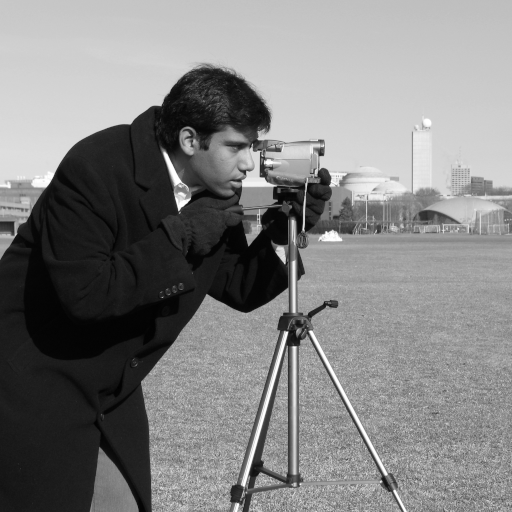

In [2]:
# ── Load image ────────────────────────────────────
cameraman = Image.fromarray(data.camera())
cameraman

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image
width, height = cameraman.size
print("Original size: ", cameraman.size)
# scaling factors
scale_x = 2
scale_y = 2

Original size:  (512, 512)


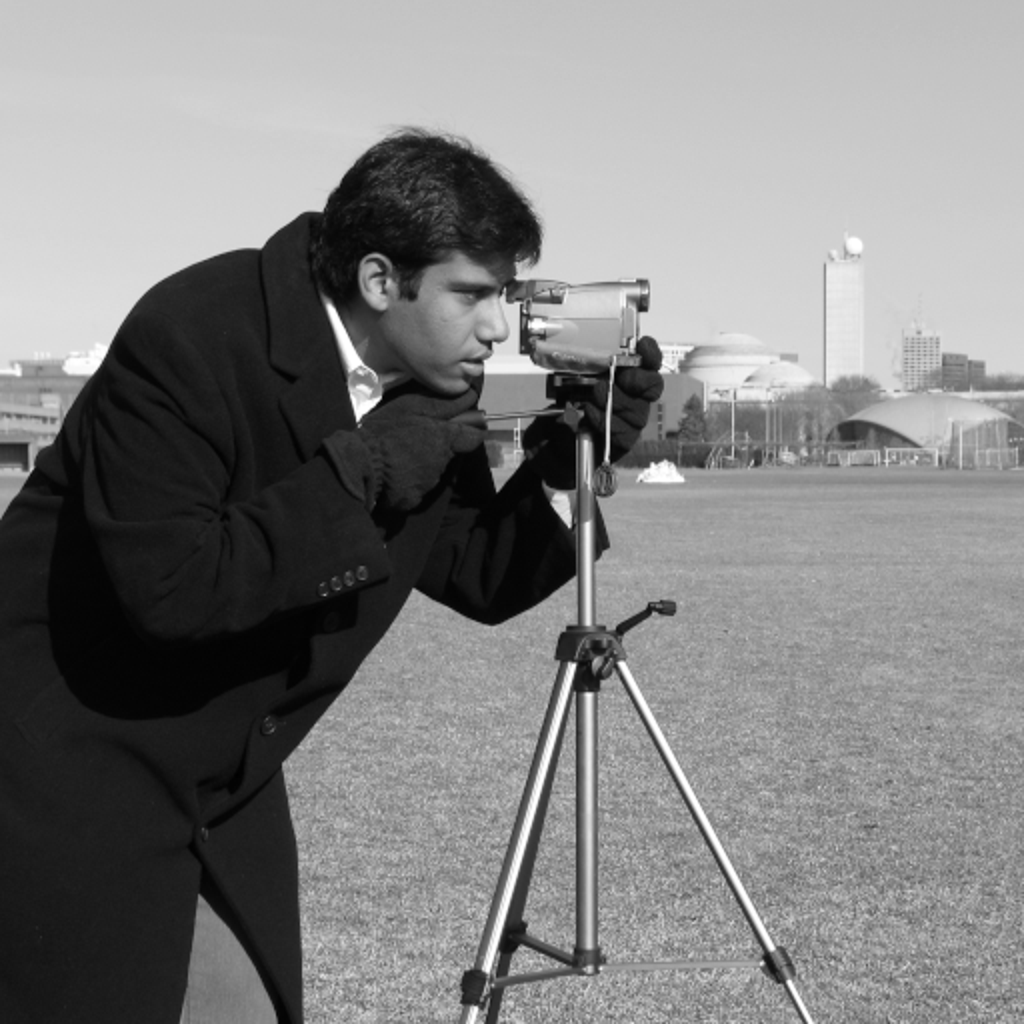

In [4]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method

resized = cameraman.resize((width * scale_x, height * scale_y))
resized

In [5]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
resized.save("task1_1_scaled.jpg")
print("Sizes after manipulation: ", resized.size)

Sizes after manipulation:  (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

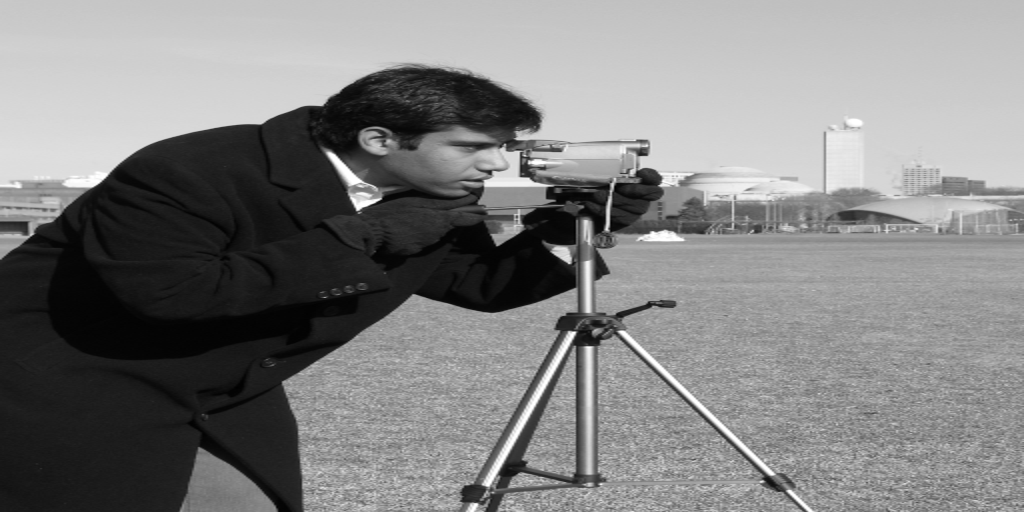

In [6]:
resize_horizontal = cameraman.resize((width * 2, height * 1))
resize_horizontal

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

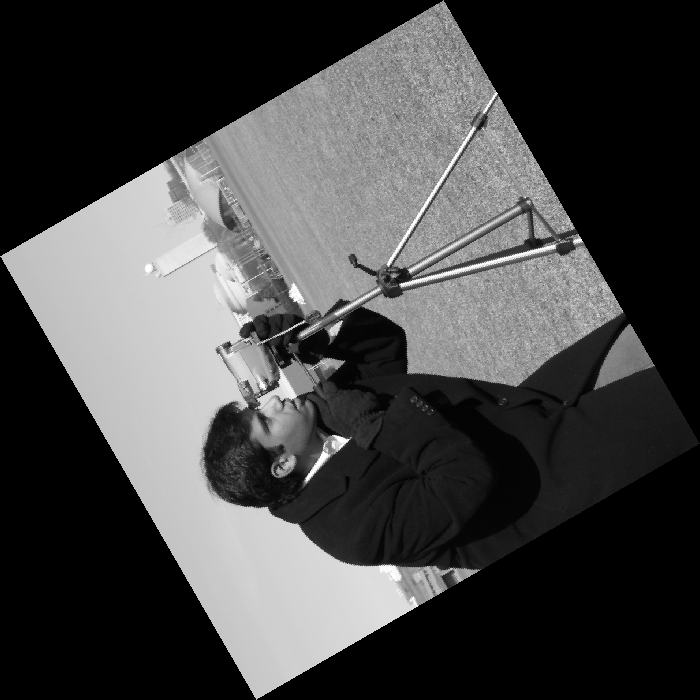

In [7]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated = cameraman.rotate(120, expand=True)
rotated.save("task1_2_rotated.jpg")
rotated

### 3. Shear

In [8]:
# -- c. Get the image dimensions ────────────────────
width, height = cameraman.size
print("Original size: ", width, height)

Original size:  512 512


In [9]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
sh = 0.5

shx = sh
shy = 0

new_width = int(width + abs(shx * height))
new_height = int(height + abs(shy * width))

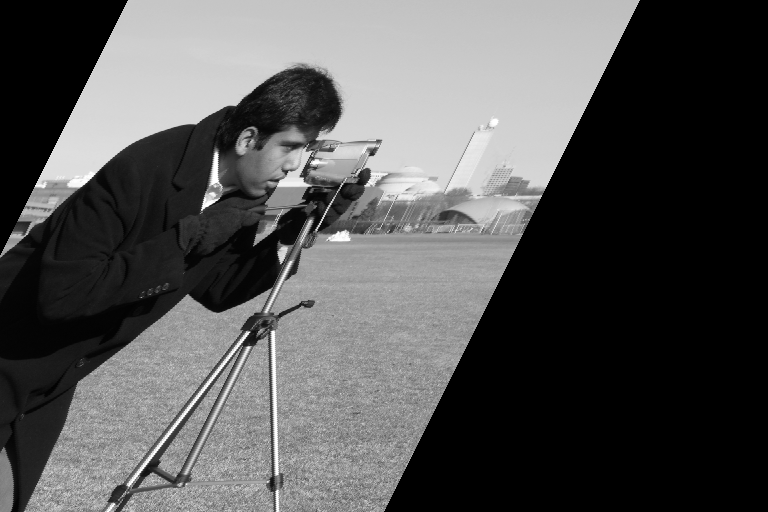

In [10]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
tx = -shx * height / 2
ty = -shy * width / 2
sheared = cameraman.transform((new_width, new_height), Image.AFFINE, (1, shx, tx, shy, 1, 0))
sheared

In [11]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared.save("task1_3_sheared.jpg")

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

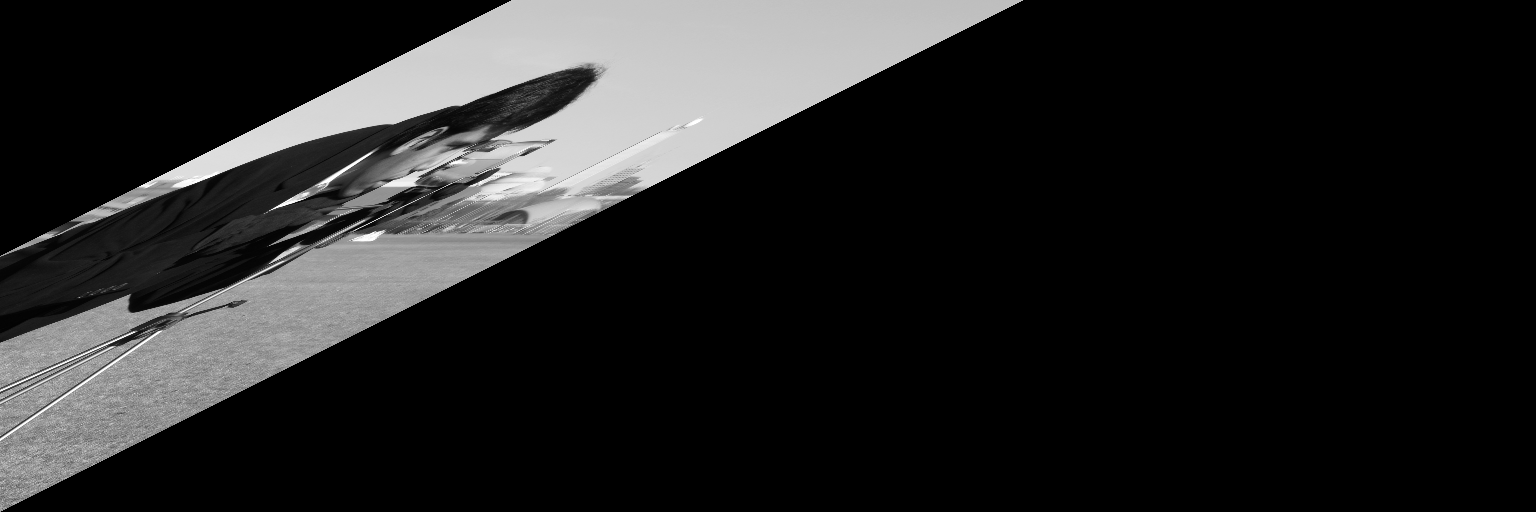

In [12]:
sh = 2.0

shx = sh
shy = 0

new_width  = int(width  + abs(shx * height))
new_height = int(height + abs(shy * width))

tx = -shx * height / 2
ty = -shy * width  / 2

sheared = cameraman.transform((new_width, new_height), Image.AFFINE, (1, shx, tx, shy, 1, 0))
sheared

# Intensity Transformations
Negative · Log · Power Law (Gamma)

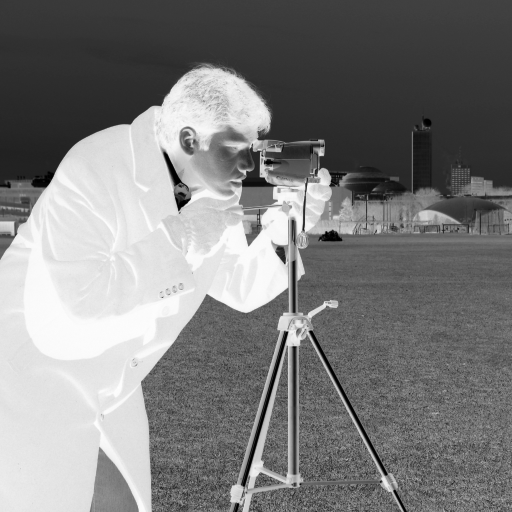

In [13]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
negative_array = np.array(cameraman)
negative = 255 - negative_array
negative_img1 = Image.fromarray(negative)
negative_img1

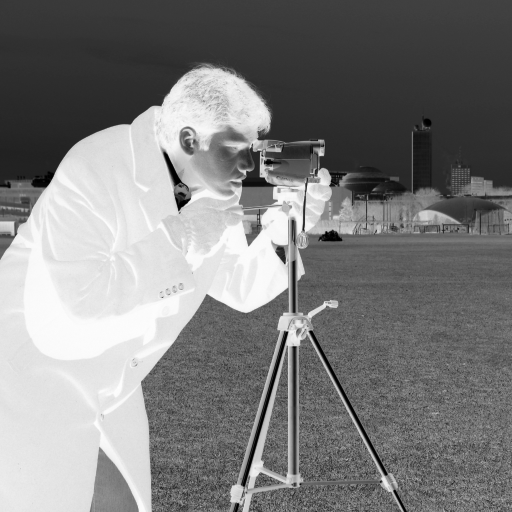

In [14]:
# Method 2: PIL's ImageOps
negative_2 = ImageOps.invert(cameraman)
negative_2

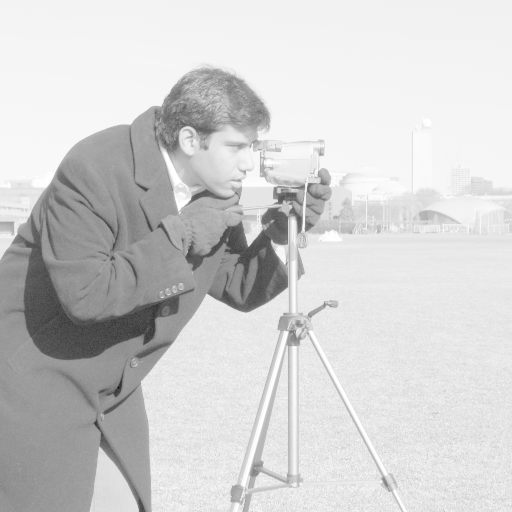

In [15]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)



# Apply the log transformation to each pixel

c = 255 / np.log(1 + 255)
img_array = np.array(cameraman, dtype=np.float64)
log_img = c * np.log(1 + img_array)
log_img = Image.fromarray(np.uint8(log_img))
log_img

In [16]:

# ── 3. Power-law / Gamma correction ───────────────


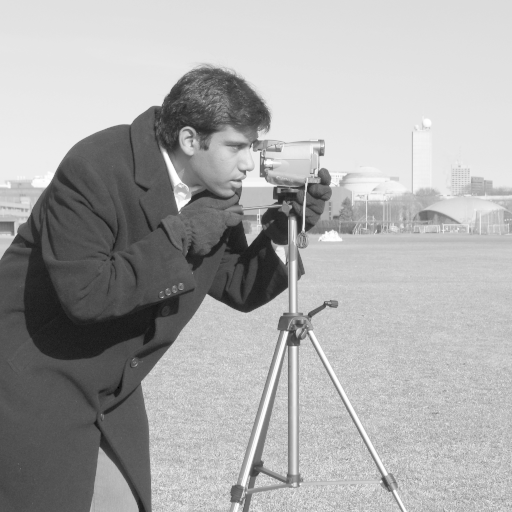

In [17]:
gamma = 0.5 
c = 255 / (255 ** gamma)

img_array = np.array(cameraman, dtype=np.float64)
gamma_img = c * (img_array ** gamma)
gamma_img = Image.fromarray(np.uint8(gamma_img))
gamma_img